# 探针 `a` 与 `path_pos` 路径对照（小测试）

- 在背景图上标出 **`dacang_track_data_final_test.csv`** 里每个 **`a`**（在 `wifi_pos` 可查到）的 **`restored_x / restored_y`**。
- 叠加 **`path_pos.csv`** 中全部折线，便于肉眼看 **哪些 OD 在表里有路径、哪些没有**。
- 最后输出：**轨迹里发生的换探针对** 中，**在 `path_pos` 的 `path` 列里找不到对应 `start->end` 行** 的对（与 `_getPath` 逻辑一致）。

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import image as mpimg

_cwd = Path.cwd().resolve()
_repo = next((p for p in [_cwd, *_cwd.parents] if (p / "utils_tool").is_dir()), _cwd)
_DACANG = _repo / "wifi_track_data" / "dacang"

F_TRACK = _DACANG / "track_data" / "dacang_track_data_final_59.csv"
F_WIFI = _DACANG / "pos_data" / "wifi_pos_new_59.csv"  # 若列名不同可改成 wifi_pos.csv
F_PATH = _DACANG / "pos_data" / "path_pos_59.csv"

# 固定底图；像素宽高在绘图 cell 由图像文件读取
BACKGROUND = _DACANG / "imgs" / "roads_600x450.png"

for p in (F_TRACK, F_WIFI, F_PATH):
    if not p.is_file():
        raise FileNotFoundError(p)
if not BACKGROUND.is_file():
    raise FileNotFoundError(BACKGROUND)
print("repo:", _repo)
print("background:", BACKGROUND)


repo: D:\Architecture\AAA-Master\26Spring\IJGIS\Human Behavior Trajectory Prediction Simulation Tool in Village Transformation
background: D:\Architecture\AAA-Master\26Spring\IJGIS\Human Behavior Trajectory Prediction Simulation Tool in Village Transformation\wifi_track_data\dacang\imgs\roads_600x450.png


In [2]:
df_track = pd.read_csv(F_TRACK)
df_wifi = pd.read_csv(F_WIFI)
df_path = pd.read_csv(F_PATH)

wifi_col = "wifi" if "wifi" in df_wifi.columns else ("WiFi" if "WiFi" in df_wifi.columns else None)
if wifi_col is None:
    raise ValueError("wifi_pos 中未找到 wifi 列，请检查列名", df_wifi.columns.tolist())

df_wifi["_id"] = df_wifi[wifi_col].astype(str).str.strip()
df_track["_a"] = df_track["a"].astype(str).str.strip()

pos = df_track[["_a"]].drop_duplicates().merge(
    df_wifi[["_id", "restored_x", "restored_y"]].drop_duplicates("_id"),
    left_on="_a",
    right_on="_id",
    how="left",
)
missing_in_wifi = pos[pos["restored_x"].isna()]["_a"].tolist()
print("轨迹中唯一 a 个数:", df_track["_a"].nunique())
print("在 wifi_pos 中找不到位置的 a 个数:", len(missing_in_wifi))
print("示例(最多30个):", missing_in_wifi[:30])

轨迹中唯一 a 个数: 166
在 wifi_pos 中找不到位置的 a 个数: 0
示例(最多30个): []


In [3]:
def parse_path_pos_row(row: pd.Series):
    """返回 (path_label, xs, ys)；跳过非 x:y 的单元格。"""
    label = str(row["path"]).strip()
    xs, ys = [], []
    for c in row.index:
        if c == "path":
            continue
        v = row[c]
        if pd.isna(v):
            continue
        s = str(v).strip()
        if ":" not in s:
            continue
        try:
            xx, yy = s.split(":", 1)
            xs.append(float(xx))
            ys.append(float(yy))
        except ValueError:
            continue
    return label, xs, ys


path_segments = []
od_in_path = set()
for _, row in df_path.iterrows():
    lab, xs, ys = parse_path_pos_row(row)
    if len(xs) < 2:
        continue
    path_segments.append((lab, xs, ys))
    if "->" in lab:
        left, right = lab.split("->", 1)
        for s in left.split(":"):
            for e in right.split(":"):
                od_in_path.add((s.strip(), e.strip()))

print("path_pos 中有坐标折线的行数:", len(path_segments))
print("由 path 列解析出的有向 OD 对数(展开多起点多终点):", len(od_in_path))

path_pos 中有坐标折线的行数: 3433
由 path 列解析出的有向 OD 对数(展开多起点多终点): 3433


In [4]:
def od_pairs_from_track(df: pd.DataFrame):
    pairs = set()
    df = df.copy()
    df["t"] = pd.to_datetime(df["t"], errors="coerce")
    # 必须先按人分组，再在每人内部按时间排序。若先全局 sort_values("t") 再 groupby("m")，
    # 同一时间戳上多人的记录交错在一起，会破坏各人内部的先后顺序，产生虚假的换探针对
    # （本数据中大量 (m,t) 重复；与 build_path_pos_59_from_graph.py 一致须用下列写法）。
    for m, g in df.groupby("m", sort=False):
        g = g.sort_values("t", kind="mergesort")
        aseq = g["_a"].tolist()
        for i in range(1, len(aseq)):
            if aseq[i - 1] != aseq[i]:
                pairs.add((str(aseq[i - 1]), str(aseq[i])))
    return pairs


od_track = od_pairs_from_track(df_track)
missing_od = sorted(od_track - od_in_path)
print("轨迹中发生的换探针对数:", len(od_track))
print("其中在 path_pos 中找不到对应 path 行的对数:", len(missing_od))
print("前 40 个缺失 OD:")
for p in missing_od[:40]:
    print("  ", p)

轨迹中发生的换探针对数: 3433
其中在 path_pos 中找不到对应 path 行的对数: 0
前 40 个缺失 OD:


C:\Users\Elena\AppData\Local\Temp\ipykernel_14224\808232145.py:133: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Elena\AppData\Local\Temp\ipykernel_14224\808232145.py:133: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Elena\AppData\Local\Temp\ipykernel_14224\808232145.py:133: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Elena\AppData\Local\Temp\ipykernel_14224\808232145.py:133: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Elena\AppData\Local\Temp\ipykernel_14224\808232145.py:133: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Elena\AppData\Local\Temp\ipykernel_14224\808232145.py:133: UserWarning: Glyph 65306 (\N{FULLWIDTH

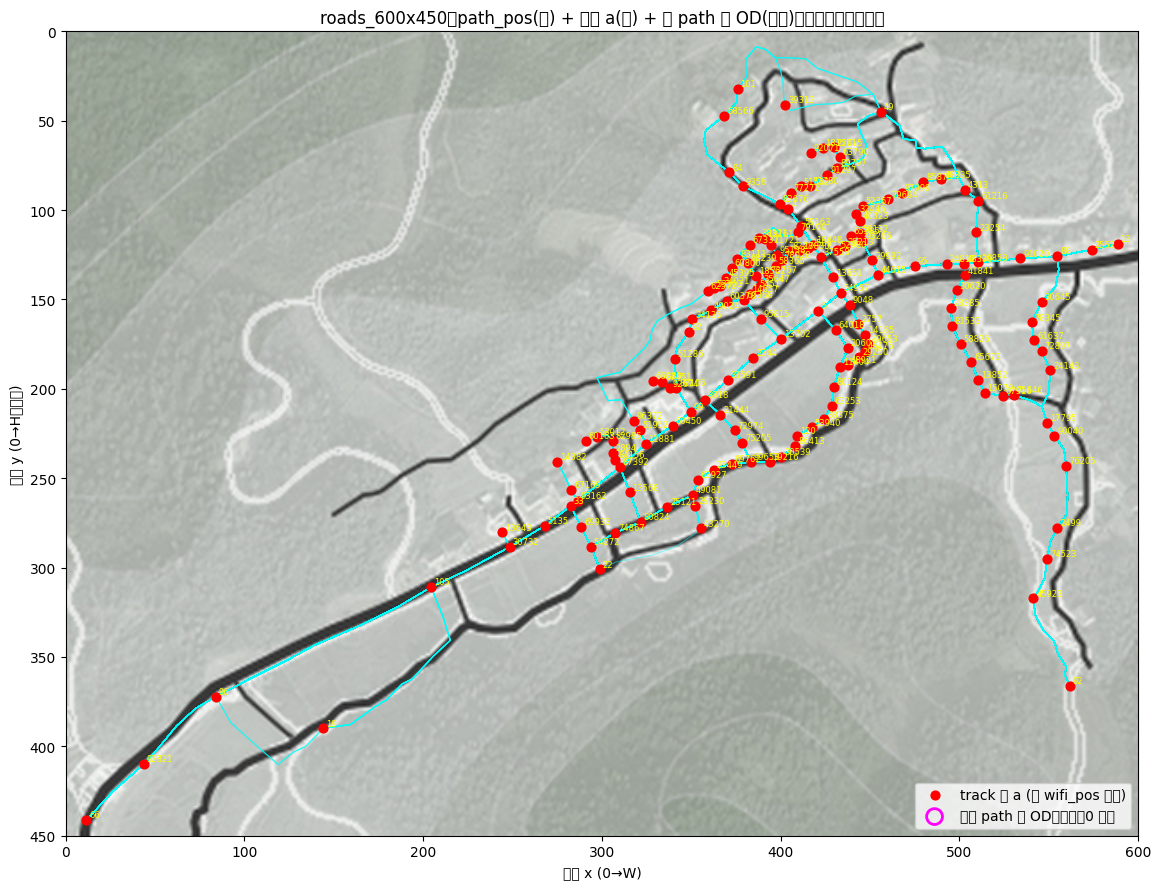

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 9))

img = mpimg.imread(str(BACKGROUND))
H, W = img.shape[0], img.shape[1]
# 以实际图像尺寸为准（一般为 600×450）
IMG_W, IMG_H = W, H


def _data_bounds():
    allx = [x for _, xs, _ in path_segments for x in xs]
    ally = [y for _, _, ys in path_segments for y in ys]
    hit2 = pos.dropna(subset=["restored_x", "restored_y"])
    allx += hit2["restored_x"].tolist()
    ally += hit2["restored_y"].tolist()
    if not allx:
        return 0.0, 1.0, 0.0, 1.0
    pad_x = max((max(allx) - min(allx)) * 0.02, 1.0)
    pad_y = max((max(ally) - min(ally)) * 0.02, 1.0)
    return (
        min(allx) - pad_x,
        max(allx) + pad_x,
        min(ally) - pad_y,
        max(ally) + pad_y,
    )


xmin, xmax, ymin, ymax = _data_bounds()
dx, dy = xmax - xmin, ymax - ymin
if dx <= 0 or dy <= 0:
    raise ValueError("数据包围盒无效")


def data_to_px(x, y):
    # 数据坐标 → 图片像素：x 向右；y 翻转以与底图路网一致
    px = (x - xmin) / dx * W
    py = H - (y - ymin) / dy * H
    return px, py


# 底图占满像素坐标；origin=upper 时第一行像素画在 y 较小一侧，配合 ylim(H,0) 与屏幕「上」一致
ax.imshow(
    img,
    extent=[0, W, H, 0],
    origin="upper",
    aspect="equal",
    interpolation="bilinear",
    zorder=0,
)

for lab, xs, ys in path_segments:
    pxs, pys = zip(*[data_to_px(x, y) for x, y in zip(xs, ys)])
    ax.plot(pxs, pys, color="cyan", linewidth=0.8, alpha=0.45, zorder=2)

hit = pos.dropna(subset=["restored_x", "restored_y"])
if len(hit) > 0:
    pxs, pys = zip(*[data_to_px(r["restored_x"], r["restored_y"]) for _, r in hit.iterrows()])
    ax.scatter(pxs, pys, s=40, c="red", zorder=4, label="track 中 a (在 wifi_pos 命中)")
    for (_, r), px, py in zip(hit.iterrows(), pxs, pys):
        ax.annotate(
            r["_a"],
            (px, py),
            fontsize=6,
            color="yellow",
            xytext=(2, 2),
            textcoords="offset points",
            zorder=5,
        )

# 在 path_pos 中无对应 path 的换探针 OD：洋红连线 + 空心端点（坐标来自 wifi_pos）
wifi_by_id = df_wifi.drop_duplicates("_id", keep="first").set_index("_id")[
    ["restored_x", "restored_y"]
]
n_missing_drawn = 0
n_missing_skip = 0
for o, d in missing_od:
    if o not in wifi_by_id.index or d not in wifi_by_id.index:
        n_missing_skip += 1
        continue
    row_o = wifi_by_id.loc[o]
    row_d = wifi_by_id.loc[d]
    x0, y0 = float(row_o["restored_x"]), float(row_o["restored_y"])
    x1, y1 = float(row_d["restored_x"]), float(row_d["restored_y"])
    if any(map(pd.isna, (x0, y0, x1, y1))):
        n_missing_skip += 1
        continue
    px0, py0 = data_to_px(x0, y0)
    px1, py1 = data_to_px(x1, y1)
    ax.plot([px0, px1], [py0, py1], color="magenta", linewidth=2.0, alpha=0.88, zorder=6)
    ax.scatter(
        [px0, px1],
        [py0, py1],
        s=130,
        facecolors="none",
        edgecolors="magenta",
        linewidths=2,
        zorder=7,
    )
    n_missing_drawn += 1

_leg_miss = f"缺失 path 的 OD（洋红，{n_missing_drawn} 对"
if n_missing_skip:
    _leg_miss += f"，未画出 {n_missing_skip}"
_leg_miss += "）"
ax.scatter(
    [],
    [],
    s=130,
    facecolors="none",
    edgecolors="magenta",
    linewidths=2,
    label=_leg_miss,
)

if missing_in_wifi:
    ax.text(
        0.02,
        0.98,
        f"wifi_pos 无坐标 a 共 {len(missing_in_wifi)} 个(未画点)",
        transform=ax.transAxes,
        va="top",
        color="white",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="black", alpha=0.45),
    )

ax.set_xlim(0, W)
ax.set_ylim(H, 0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("像素 x (0→W)")
ax.set_ylabel("像素 y (0→H，向下)")
ax.set_title("roads_600x450：path_pos(青) + 轨迹 a(红) + 无 path 的 OD(洋红)，数据坐标线性映射")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 说明

- **底图**：固定 `wifi_track_data/dacang/imgs/roads_600x450.png`（600×450 像素）。
- **坐标系**：以**图片像素**为基准，`x∈[0,W]`、`y∈[0,H]` 且 **y 向下增大**（与图像行方向一致）。`path_pos` 与 `wifi_pos` 的平面坐标先取全体折线+命中点的包围盒，再**分别线性映射**到 `[0,W]`、`[0,H]`（填满整图；若数据宽高比与 600:450 不同会有拉伸）。
- **若 y 仍反**：把 `data_to_px` 里 `py` 改回 `(y - ymin) / dy * H`（取消翻转）。
- **缺失 OD**：`missing_od` 与 `utils._getPath` 一致。
- **`wifi_pos` 文件**：默认 `wifi_pos_new_59.csv`；可改 **Cell 1** 里 `F_WIFI`。


C:\Users\Elena\AppData\Local\Temp\ipykernel_14224\4252734396.py:90: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Elena\AppData\Local\Temp\ipykernel_14224\4252734396.py:90: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Elena\AppData\Local\Temp\ipykernel_14224\4252734396.py:90: UserWarning: Glyph 24213 (\N{CJK UNIFIED IDEOGRAPH-5E95}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Elena\AppData\Local\Temp\ipykernel_14224\4252734396.py:90: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Elena\AppData\Local\Temp\ipykernel_14224\4252734396.py:90: UserWarning: Glyph 32511 (\N{CJK UNIFIED IDEOGRAPH-7EFF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Elena\AppData\Local\Temp\ipykernel_14224\4252734396.py:90: UserWarning: Glyph 36712 (\

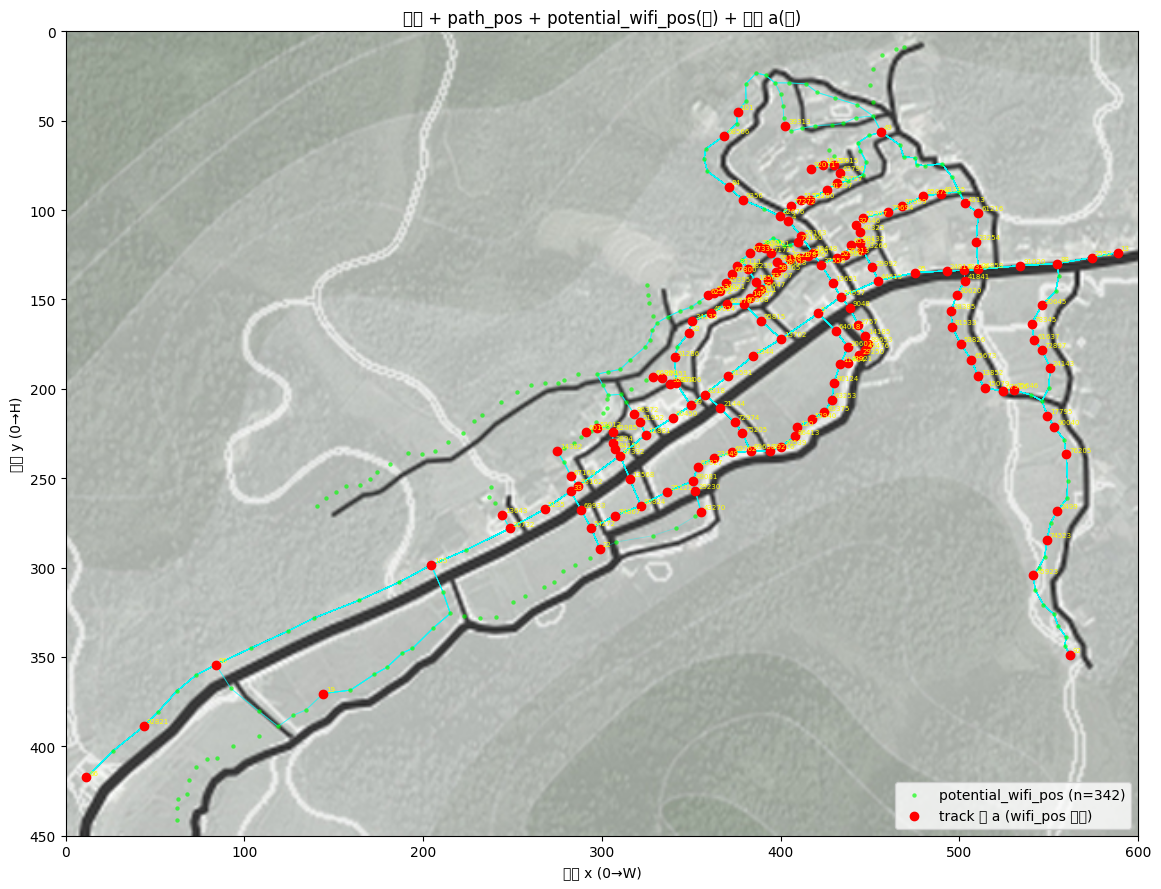

In [6]:
# 将 potential_wifi_pos 映射到与 roads_600x450 同一套像素坐标（需先跑完前面加载 path_segments、pos、BACKGROUND 的单元格）
from matplotlib import image as mpimg

F_POTENTIAL = _DACANG / "pos_data" / "potential_wifi_pos.csv"
df_pot = pd.read_csv(F_POTENTIAL)
if not {"X", "Y"}.issubset(df_pot.columns):
    raise ValueError("potential_wifi_pos.csv 需包含列 X, Y", df_pot.columns.tolist())


def _bounds_with_potential():
    allx = [x for _, xs, _ in path_segments for x in xs]
    ally = [y for _, _, ys in path_segments for y in ys]
    hit2 = pos.dropna(subset=["restored_x", "restored_y"])
    allx += hit2["restored_x"].tolist()
    ally += hit2["restored_y"].tolist()
    allx += df_pot["X"].astype(float).tolist()
    ally += df_pot["Y"].astype(float).tolist()
    pad_x = max((max(allx) - min(allx)) * 0.02, 1.0)
    pad_y = max((max(ally) - min(ally)) * 0.02, 1.0)
    return (
        min(allx) - pad_x,
        max(allx) + pad_x,
        min(ally) - pad_y,
        max(ally) + pad_y,
    )


img = mpimg.imread(str(BACKGROUND))
H, W = img.shape[0], img.shape[1]
xmin, xmax, ymin, ymax = _bounds_with_potential()
dx, dy = xmax - xmin, ymax - ymin
if dx <= 0 or dy <= 0:
    raise ValueError("包围盒无效")


def _data_to_px(x, y):
    px = (x - xmin) / dx * W
    py = H - (y - ymin) / dy * H
    return px, py


fig, ax = plt.subplots(1, 1, figsize=(12, 9))
ax.imshow(
    img,
    extent=[0, W, H, 0],
    origin="upper",
    aspect="equal",
    interpolation="bilinear",
    zorder=0,
)

for lab, xs, ys in path_segments:
    pxs, pys = zip(*[_data_to_px(x, y) for x, y in zip(xs, ys)])
    ax.plot(pxs, pys, color="cyan", linewidth=0.6, alpha=0.35, zorder=1)

pxp, pyp = zip(*[_data_to_px(float(r["X"]), float(r["Y"])) for _, r in df_pot.iterrows()])
ax.scatter(
    pxp,
    pyp,
    s=10,
    c="lime",
    alpha=0.65,
    linewidths=0,
    zorder=3,
    label=f"potential_wifi_pos (n={len(df_pot)})",
)

hit = pos.dropna(subset=["restored_x", "restored_y"])
if len(hit) > 0:
    pxs, pys = zip(*[_data_to_px(r["restored_x"], r["restored_y"]) for _, r in hit.iterrows()])
    ax.scatter(pxs, pys, s=36, c="red", zorder=4, label="track 中 a (wifi_pos 命中)")
    for (_, r), px, py in zip(hit.iterrows(), pxs, pys):
        ax.annotate(
            r["_a"],
            (px, py),
            fontsize=5,
            color="yellow",
            xytext=(2, 2),
            textcoords="offset points",
            zorder=5,
        )

ax.set_xlim(0, W)
ax.set_ylim(H, 0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("像素 x (0→W)")
ax.set_ylabel("像素 y (0→H)")
ax.set_title("底图 + path_pos + potential_wifi_pos(绿) + 轨迹 a(红)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [7]:
# 由 graph（nodes/edges）+ wifi_pos_new_59 + dacang_track_data_final_59 生成 path_pos_59.csv
# 需先运行 Cell 1 得到 `_repo` / `_DACANG`。输出：`pos_data/path_pos_59.csv`，宽表格式同 `path_pos.csv`。
# 脚本会检查：轨迹中每个探针 a 均在 wifi_pos 中有行，且最近邻 node 属于 edges 构成的图；否则全部 print。
import runpy

_script = _repo / "wifi_track_data" / "dacang" / "pos_data" / "build_path_pos_59_from_graph.py"
if not _script.is_file():
    raise FileNotFoundError(str(_script))
runpy.run_path(str(_script), run_name="__main__")
print("输出:", _DACANG / "pos_data" / "path_pos_59.csv")

--- 轨迹探针 与 graph 映射检查 ---
轨迹唯一探针 a 个数: 166
OK: 全部唯一探针均在 wifi_pos_new_59 中有对应行。
OK: 凡已在 wifi_pos 中的探针，其最近邻 node_id 均在 edges 构成的图中（图顶点数 342，边数 362）。
Wrote D:\Architecture\AAA-Master\26Spring\IJGIS\Human Behavior Trajectory Prediction Simulation Tool in Village Transformation\wifi_track_data\dacang\pos_data\path_pos_59.csv rows: 3433 max vertex columns: 64
输出: D:\Architecture\AAA-Master\26Spring\IJGIS\Human Behavior Trajectory Prediction Simulation Tool in Village Transformation\wifi_track_data\dacang\pos_data\path_pos_59.csv
